In [1]:
import anndata
import pandas as pd
from scipy import sparse
import h5py
from pathlib import Path
import squidpy as sq
import scanpy as sc
import mygene
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
currentpath   = Path.cwd()
filepath      = currentpath / "A1/outs/binned_outputs/square_008um/filtered_feature_bc_matrix.h5"
clusterspath  = currentpath / "A1/outs/binned_outputs/square_008um/analysis/clustering/gene_expression_graphclust/clusters.csv"
positionspath = currentpath / "A1/outs/binned_outputs/square_008um/spatial/tissue_positions.parquet"
differential_expression_path = currentpath / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "diffexp" / "gene_expression_graphclust" / "differential_expression.csv"


# 1. Load matrix + barcodes
with h5py.File(filepath, "r") as f:
    data     = f["matrix/data"][:]
    indices  = f["matrix/indices"][:]
    indptr   = f["matrix/indptr"][:]
    shape    = f["matrix/shape"][:]
    barcodes = f["matrix/barcodes"][:].astype(str)
    genes    = f["matrix/features/name"][:].astype(str)

X = sparse.csc_matrix((data, indices, indptr), shape=shape)   # genes x spots

# 2. Load clusters and get the set of clustered barcodes
clustersdf = pd.read_csv(clusterspath)              # Barcode,Cluster
clustersdf = clustersdf.rename(columns={"Barcode": "barcode"})
cluster_bcs = clustersdf["barcode"].astype(str)

# 3. Find the indices in the matrix that correspond to clustered barcodes
bc_to_idx = {bc: i for i, bc in enumerate(barcodes)}
valid_idx = [bc_to_idx[bc] for bc in cluster_bcs if bc in bc_to_idx]

print("found", len(valid_idx), "clustered barcodes in matrix")

# 4. Subset matrix to those columns and create AnnData
X_sub = X[:, valid_idx]                             # genes x clustered_spots
adata = anndata.AnnData(X=X_sub.T)                  # cells x genes

# align names
adata.obs_names = cluster_bcs.tolist()              # same order as clustersdf
adata.var_names = genes

# 5. Attach clusters (now aligned by order)
adata.obs["Cluster"] = clustersdf["Cluster"].values.astype(int)

# 6. Map to cell types
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
adata.obs["cell_type"] = adata.obs["Cluster"].map(cluster_to_ct).astype("category")

print(adata.obs["cell_type"].value_counts())

found 161641 clustered barcodes in matrix
cell_type
Ovarian.cancer.cell    50843
Fibroblast             49712
Unknown                36776
Myeloid.cell           21400
Endothelial.cell        2910
Name: count, dtype: int64


In [3]:
# optional: add spatial coords for these barcodes
positionsdf = pd.read_parquet(positionspath)
positionsdf = positionsdf.set_index("barcode")
coords = positionsdf.loc[adata.obs_names, ["pxl_row_in_fullres", "pxl_col_in_fullres"]].to_numpy()
adata.obsm["spatial"] = coords

In [4]:
# Keep only in-tissue spots
pos = positionsdf[positionsdf["in_tissue"] == 1].copy()

# Merge cluster labels onto positions
pos = pos.merge(clustersdf, on="barcode", how="inner")
# pos now has: in_tissue, array_row, array_col, pxl_row_in_fullres,
#              pxl_col_in_fullres, barcode, Cluster


In [5]:
# Determine grid size
n_rows = pos["array_row"].max() + 1
n_cols = pos["array_col"].max() + 1

# Initialize grid with -1 = empty
cluster_grid = np.full((n_rows, n_cols), fill_value=-1, dtype=int)

# Fill with cluster IDs
for _, r in pos.iterrows():
    i = int(r["array_row"])
    j = int(r["array_col"])
    cluster_grid[i, j] = int(r["Cluster"])

In [6]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)

def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts

radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Convert to fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [7]:
interaction = np.zeros((n_types, n_types), dtype=float)  # focal x neighbor
focal_counts = np.zeros(n_types, dtype=int)

n_rows, n_cols = cluster_grid.shape
for i in range(n_rows):
    for j in range(n_cols):
        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue
        f_idx = focal_type - 1
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

# Average across bins of each focal type
for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [8]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]

interaction_df = pd.DataFrame(
    interaction,
    index=labels,   # focal bin type
    columns=labels  # neighbor type
)
interaction_df

,Ovarian.cancer.cell,Fibroblast,Unknown,Myeloid.cell,Endothelial.cell
Ovarian.cancer.cell,0.869784,0.083934,0.020180,0.021390,0.004711
Fibroblast,0.085855,0.725309,0.094942,0.078421,0.015473
Unknown,0.028430,0.129069,0.758841,0.071165,0.006133
Myeloid.cell,0.050802,0.182179,0.120318,0.638028,0.008673
Endothelial.cell,0.082372,0.264380,0.077341,0.063841,0.512065


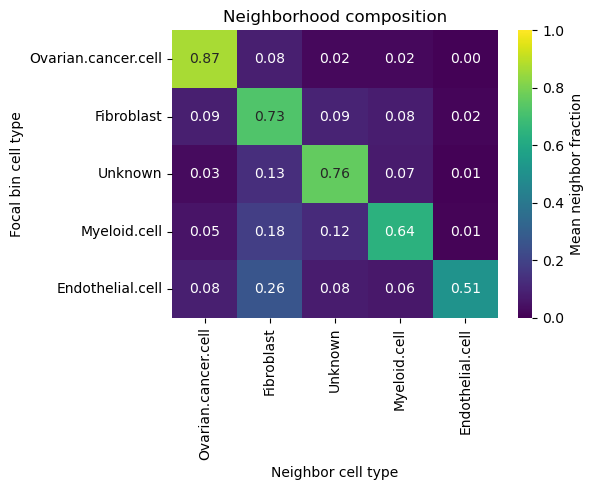

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition")
plt.tight_layout()
plt.show()

In [10]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)


def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts


radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [11]:
n_rows, n_cols = cluster_grid.shape

contour_mask = np.zeros((n_rows, n_cols), dtype=bool)

for i in range(n_rows):
    for j in range(n_cols):
        center_type = cluster_grid[i, j]
        if center_type == -1:
            continue

        tot = total_neighbors[i, j, 0]
        if tot == 0:
            continue

        same = neighbor_counts_arr[i, j, center_type - 1]
        diff = tot - same

        # criterion: at least half neighbors are different types
        if diff >= 0.5 * tot:
            contour_mask[i, j] = True

In [12]:
interaction = np.zeros((n_types, n_types), dtype=float)  # focal x neighbor
focal_counts = np.zeros(n_types, dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        if not contour_mask[i, j]:
            continue

        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue

        f_idx = focal_type - 1
        # use neighbor_fracs_arr here, already normalized
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [13]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]
interaction_df = pd.DataFrame(interaction, index=labels, columns=labels)

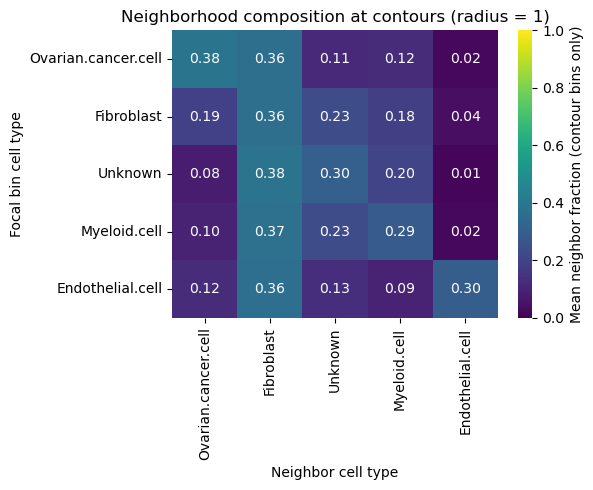

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction (contour bins only)"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition at contours (radius = {radius})")
plt.tight_layout()
plt.show()

In [15]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)


def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts


radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [16]:
# 1) Per-bin total, same-type, different-type counts
total_counts = neighbor_counts_arr.sum(axis=-1)  # shape (n_rows, n_cols)
same_type_counts = np.zeros((n_rows, n_cols), dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        center_type = cluster_grid[i, j]
        if center_type == -1:
            continue
        same_type_counts[i, j] = neighbor_counts_arr[i, j, center_type - 1]

diff_type_counts = total_counts - same_type_counts

In [17]:
# 2) Explore thresholds to see how many bins are "contour"
valid_bins = (cluster_grid != -1)

for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    mask = (    
        (total_counts > 0) &
        (diff_type_counts >= thr * total_counts) &
        valid_bins
    )
    frac = mask.sum() / valid_bins.sum()
    print(f"thr={thr}: {frac:.2%} of bins are contour")

thr=0.2: 43.84% of bins are contour
thr=0.3: 33.08% of bins are contour
thr=0.4: 23.07% of bins are contour
thr=0.5: 22.90% of bins are contour
thr=0.6: 14.69% of bins are contour
thr=0.7: 8.89% of bins are contour
thr=0.8: 4.99% of bins are contour


In [18]:
thr = 0.8  # choose based on the diagnostics above
contour_mask = (
    (total_counts > 0) &
    (diff_type_counts >= thr * total_counts) &
    valid_bins
)

In [19]:
interaction = np.zeros((n_types, n_types), dtype=float)
focal_counts = np.zeros(n_types, dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        if not contour_mask[i, j]:
            continue

        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue

        f_idx = focal_type - 1
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [20]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]
interaction_df = pd.DataFrame(interaction, index=labels, columns=labels)

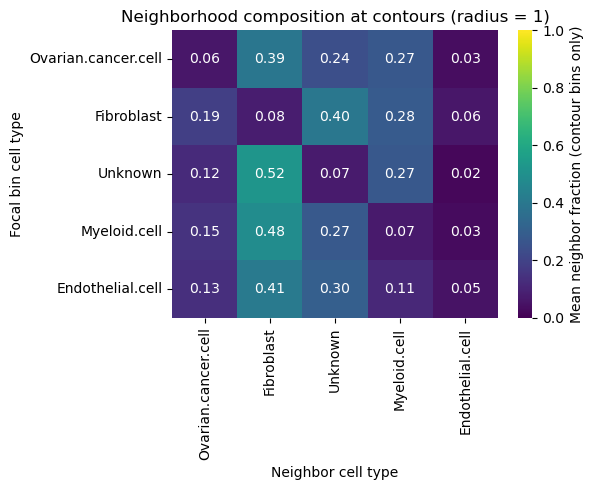

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction (contour bins only)"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition at contours (radius = {radius})")
plt.tight_layout()
plt.show()

Ovarian.cancer.cell ↔ Ovarian.cancer.cell: very strong self‑enrichment (bright yellow) → tumor cells are spatially clustered (solid tumor islands).

Fibroblast ↔ Fibroblast, Myeloid.cell ↔ Myeloid.cell, Unknown ↔ Unknown: clear self‑enrichment → each forms its own niches.

Ovarian.cancer.cell with Fibroblast / Myeloid.cell: values look slightly negative to neutral → immune/stromal cells are more at the periphery of tumor clusters rather than perfectly mixed.

Endothelial.cell with others: mostly mild/neutral enrichment → vessels are relatively dispersed, not strongly co‑localized with a specific compartment.

In [23]:
keep = adata.obs["cell_type"].isin(
    ["Ovarian.cancer.cell", "Fibroblast", "Myeloid.cell"]
)
adata_sub = adata[keep].copy()
# optional further downsample for testing:
# sc.pp.subsample(adata_sub, n_obs=30000, random_state=0)

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Co-occurrence analysis of tumor, fibroblast, and myeloid niches

To quantify how **cell types co-occur as a function of spatial distance**, we computed Squidpy’s co-occurrence score on a downsampled subset of the data. This avoids the heavy memory/runtime cost of running the statistic on all spots while still capturing representative spatial patterns.


**Logic and statistic.**  
`sq.gr.co_occurrence` estimates, for each pair of cell types A (exp) and B (cond), the **co-occurrence ratio** as a function of radius *r*:  

$$
\text{co-occurrence}(A|B, r) = \frac{P(A \text{ within distance } r \mid B)}{P(A \text{ within distance } r)}
$$

- $P(A \mid B)$ is the conditional probability of finding $A$ within radius $r$ around $B$.  
- $P(A)$ is the global probability of $A$ within radius $r$ in the tissue.  
- Values **> 1** indicate that $A$ is enriched around $B$ at that distance; values **< 1** indicate spatial avoidance. 

**Expected output.**  
`sq.pl.co_occurrence` produces a line plot where:

- The **x-axis** is distance from each reference cell type (e.g., 0–200–400–… µm).  
- The **y-axis** is the **co-occurrence ratio**.  
- Each line shows how much a given **cell_type A** tends to be found near **cell_type B** as radius increases (often plotted for one “conditioning” cell type at a time).

In our context, these curves allow us to ask questions such as:

- *Are fibroblasts enriched within ~200–400 µm of ovarian cancer cells?*  
- *Do myeloid cells cluster close to tumor islands at short distances but not at larger radii?*

Together with neighborhood enrichment, this provides a distance-resolved view of **tumor–stroma–immune spatial organization** in the ovarian cancer microenvironment. 

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


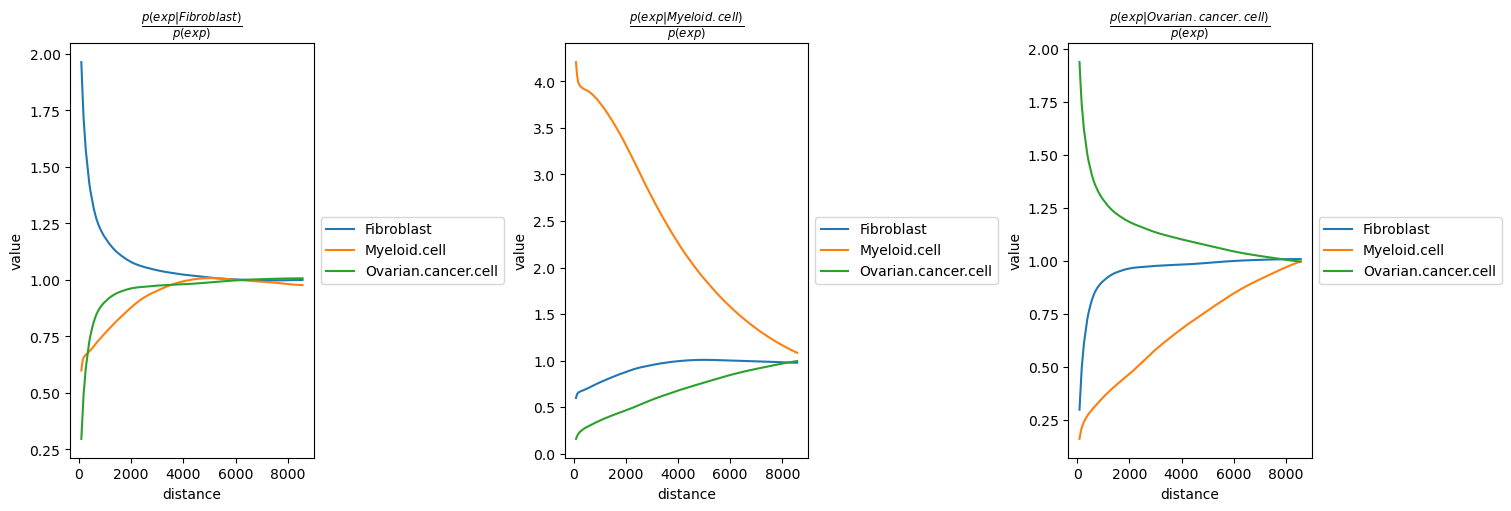

In [ ]:
# tiny subset just to confirm it runs
adata_test = adata_sub[:].copy()
sq.gr.co_occurrence(
    adata_test,
    cluster_key="cell_type",
    interval=200,
    n_splits=None,
    n_jobs=2,
    show_progress_bar=False,  # ignore bar
)

clusters: ['Fibroblast' 'Myeloid.cell' 'Ovarian.cancer.cell']


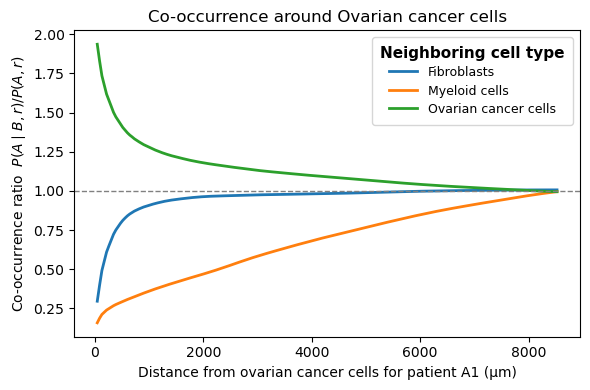

In [50]:
# ------------------------------------------------------------------
# 2. Extract result and build long-format DataFrame
# ------------------------------------------------------------------
co = adata_test.uns["cell_type_co_occurrence"]
occ = np.asarray(co["occ"])          # (n_exp, n_cond, n_radii)
radii = np.asarray(co["interval"])   # (n_radii,)

clusters = adata_test.obs["cell_type"].cat.categories.to_numpy()
print("clusters:", clusters)

n_exp, n_cond, n_r = occ.shape

records = []
for i_exp in range(n_exp):
    for j_cond in range(n_cond):
        for k_r in range(n_r):
            records.append(
                {
                    "radius": radii[k_r],
                    "exp": clusters[i_exp],
                    "cond": clusters[j_cond],
                    "ratio": occ[i_exp, j_cond, k_r],
                }
            )

df_co = pd.DataFrame(records)

# ------------------------------------------------------------------
# 3. Single-panel plot: Ovarian.cancer.cell as reference (like right panel)
# ------------------------------------------------------------------
cond_of_interest = "Ovarian.cancer.cell"  # EXACT match from df_co["cond"]

rename_map = {
    "Fibroblast": "Fibroblasts",
    "Myeloid.cell": "Myeloid cells",
    "Ovarian.cancer.cell": "Ovarian cancer cells",
}
keep_exp = list(rename_map.keys())

df_ref = df_co[
    (df_co["cond"] == cond_of_interest) &
    (df_co["exp"].isin(keep_exp))
].copy()
df_ref["exp_pretty"] = df_ref["exp"].map(rename_map)

plt.figure(figsize=(6, 4))
ax = sns.lineplot(
    data=df_ref,
    x="radius",
    y="ratio",
    hue="exp_pretty",
    lw=2,
)

ax.axhline(1.0, color="grey", ls="--", lw=1)

ax.set_xlabel("Distance from ovarian cancer cells for patient A1 (µm)")
ax.set_ylabel(r"Co-occurrence ratio  $P(A\mid B,r)/P(A,r)$")
ax.set_title("Co-occurrence around Ovarian cancer cells")

leg = ax.legend(
    title="Neighboring cell type",
    loc="upper right",
    frameon=True,
    borderpad=0.6,
    labelspacing=0.4,
)
plt.setp(leg.get_title(), fontsize=11, fontweight="bold")
plt.setp(leg.get_texts(), fontsize=9)

plt.tight_layout()
plt.show()

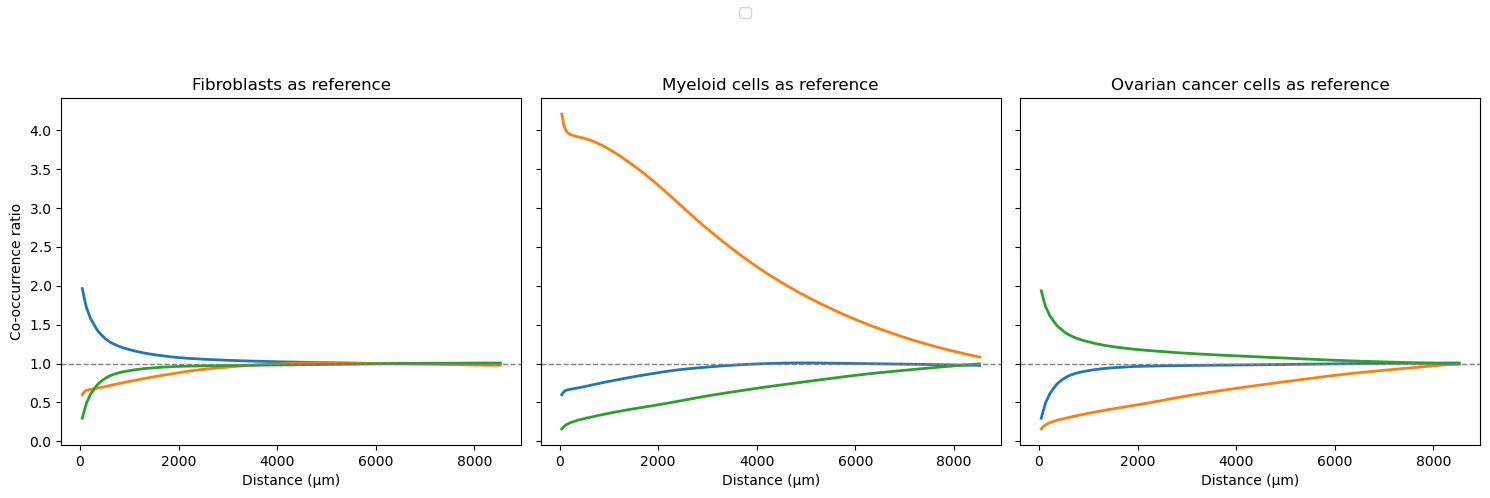

In [48]:
# ------------------------------------------------------------------
# 4. Three-panel plot matching Squidpy panels, with a single legend
# ------------------------------------------------------------------
conds = ["Fibroblast", "Myeloid.cell", "Ovarian.cancer.cell"]

fig, axes = plt.subplots(1, len(conds), figsize=(15, 5), sharey=True)

for ax, cond in zip(axes, conds):
    df_cond = df_co[
        (df_co["cond"] == cond) &
        (df_co["exp"].isin(conds))
    ].copy()
    df_cond["exp_pretty"] = df_cond["exp"].map(rename_map)
    
    sns.lineplot(
        data=df_cond,
        x="radius",
        y="ratio",
        hue="exp_pretty",
        lw=2,
        ax=ax,
        legend=False,  # no legend on each axis
    )
    ax.axhline(1.0, color="grey", ls="--", lw=1)
    ax.set_title(f"{rename_map.get(cond, cond)} as reference")
    ax.set_xlabel("Distance (µm)")
    if ax is axes[0]:
        ax.set_ylabel("Co-occurrence ratio")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(conds),
    frameon=True,
)

plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

### Ripley’s L: quantifying spatial clustering of cell types

To assess whether each **cell type** forms clustered, random, or regularly spaced patterns across spatial scales, we used **Ripley’s L function** on a downsampled subset of cells.

**Logic of the statistic.**  
Ripley’s K function $K(r)$ measures, for a given radius $r$, the **expected number of points within distance $r$ of an arbitrary point**, normalized by the overall point density. Under **complete spatial randomness (CSR)** in 2D, $K(r) = \pi r^2$. The **L function** is a variance‑stabilized version:

$$
\hat{L}(r) = \sqrt{\frac{\hat{K}(r)}{\pi}}.
$$


Under CSR, $\hat{L}(r) \approx r$., so **steeper or higher $L(r)$ curves indicate stronger clustering** (more neighbors than expected) at the corresponding distances. Flatter, lower curves indicate a more diffuse or nearly random pattern.

`sq.pl.ripley` plots $L(r)$ versus distance for each **cell_type**, so we can directly compare how strongly different cell types cluster. In our data, **ovarian cancer cells and fibroblasts show higher $L(r)$ curves than myeloid cells across the sampled distances, indicating stronger spatial clustering of tumor and fibroblast niches compared to more diffusely distributed myeloid cells.** [web:278][web:324]

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


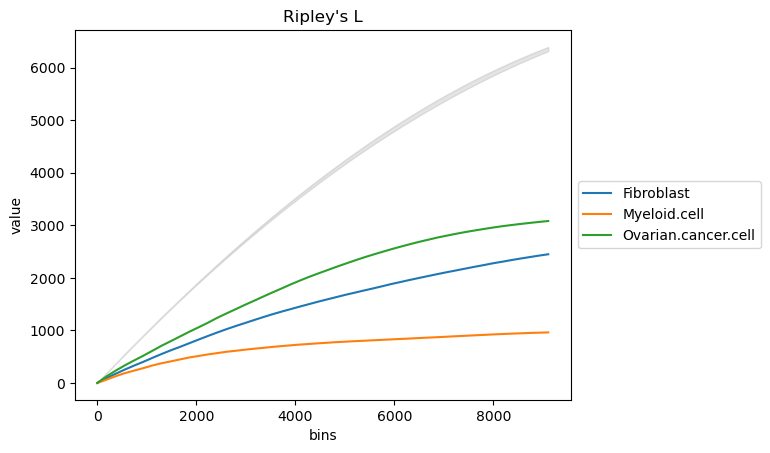

In [52]:
adata_test = adata_sub[:1000].copy()

# compute Ripley’s L (variance‑stabilized K), usually the most interpretable
sq.gr.ripley(
    adata_test,
    cluster_key="cell_type",
    mode="L",              # 'F', 'G', or 'L'; L ≈ K-based clustering measure
    spatial_key="spatial", # or your key in .obsm
    n_simulations=100,     # permutation sims for confidence bands
)

sq.pl.ripley(
    adata_test,
    cluster_key="cell_type",
    mode="L",
)

In [53]:
diffexp_df = pd.read_csv(differential_expression_path)


# Example: column names – adapt to your real ones
# "Feature Name" is your gene symbol or Ensembl ID
# "Cluster 1 Log2 fold change", "Cluster 1 Adjusted p value", etc.

marker_genes = []

for k in range(1, 6):  # clusters 1..5
    lfc_col = f"Cluster {k} Log2 fold change"
    p_col   = f"Cluster {k} Adjusted p value"
    
    df_k = diffexp_df[
        (diffexp_df[p_col] < 0.05) &
        (diffexp_df[lfc_col] > 0)
    ].copy()
    
    # sort by effect size, take top 20
    df_k = df_k.sort_values(lfc_col, ascending=False).head(20)
    
    genes_k = df_k["Feature Name"].tolist()  # or "Feature ID" if that matches adata.var_names
    marker_genes.extend(genes_k)

marker_genes = list(set(marker_genes))
print("Number of selected markers:", len(marker_genes))

Number of selected markers: 100


In [54]:
# Optionally keep raw counts
adata.raw = adata.copy()

# Normalize & log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Moran’s I: spatial autocorrelation of CD9 and CD55

We next asked whether key genes show **non‑random spatial patterns** (e.g. higher expression in specific niches) using **Moran’s I**, a global spatial autocorrelation statistic implemented in Squidpy


**Logic of the statistic.**  
For each gene, Moran’s I measures whether **similar expression values tend to occur at nearby locations** more than expected by chance: 

- $I > 0$: nearby spots have **similar expression** → **spatial clustering** of high/low values.  
- $I = 0$: pattern compatible with **spatial randomness**.  
- $I < 0$: nearby spots tend to be **dissimilar** → **spatial dispersion** or checkerboard patterns.  

Squidpy stores the results (Moran’s I, p‑values, etc.) in `adata_test.uns["moranI"]`, allowing us to quantify which genes are spatially structured.

To **visualize where** these genes are expressed in the tissue, we overlay their expression on spatial coordinates:

These scatter plots show **expression intensity in physical space**, so together with Moran’s I we can report, for example, that **CD9 and CD55 exhibit significantly positive spatial autocorrelation, with expression concentrated in specific tumor or stromal regions rather than randomly distributed across the section.** 

CD9 True
CD55 True
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 100/100 [00:16<00:00,  5.98/s]


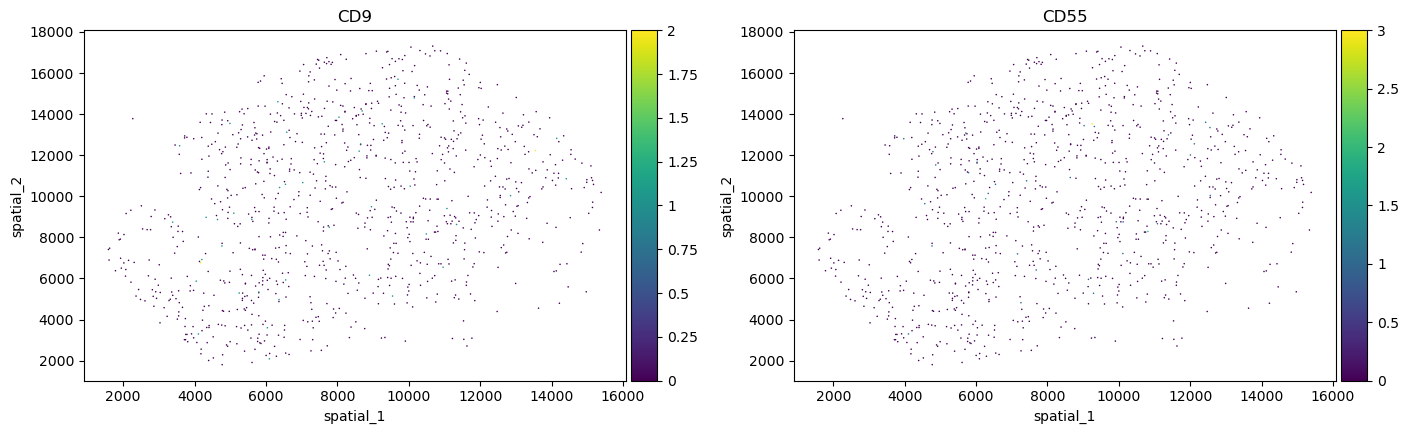

In [55]:
# 1. Make sure cell IDs and gene names are unique
adata_test.obs_names_make_unique()
adata_test.var_names_make_unique()

# 2. Check that the genes you want actually exist in var_names
for g in ["CD9", "CD55"]:
    print(g, g in adata_test.var_names)

# 3. Recompute neighbors (once) and Moran's I
sq.gr.spatial_neighbors(adata_test, coord_type="generic")

sq.gr.spatial_autocorr(
    adata_test,
    mode="moran",
    genes=["CD9", "CD55"],
    use_raw=False,          # be explicit: work on adata.X
    n_perms=100,
    n_jobs=4,
)

adata_test.obs[["spatial_1", "spatial_2"]] = adata_test.obsm["spatial"]
sc.pl.scatter(
    adata_test,
    x="spatial_1",
    y="spatial_2",
    color=["CD9", "CD55"],
    size=5
)

In [57]:
# 1. Make sure cell IDs and gene names are unique
adata.obs_names_make_unique()
adata.var_names_make_unique()

# 2. Check that the genes you want actually exist in var_names
for g in marker_genes:
    print(g, g in adata.var_names)

# 3. Recompute neighbors (once) and Moran's I
sq.gr.spatial_neighbors(adata, coord_type="generic")

sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=marker_genes,
    use_raw=False,          # be explicit: work on adata.X
    n_perms=100,
    n_jobs=4,
)


ENSG00000287778 True
HBB True
ACKR4 True
LINC02432 True
NRSN2-AS1 True
ENSG00000272732 True
SCGB1A1 True
TSPYL2 True
ZNF365 True
EMCN True
ASPA True
GOLT1A True
ARG1 True
ECSCR True
CSMD3 True
BHLHE22 True
NEGR1 True
HBA1 True
FAM162B True
ESAM True
ENSG00000287088 True
CRYBB2P1 True
OVOL1 True
LINC02228 True
MIR223HG True
PON3 True
SYNPO True
SORCS1 True
GAP43 True
TM4SF18 True
FGR True
VWDE True
ENSG00000260476 True
C12orf56 True
CYP4F3 True
G0S2 True
LINC00539 True
MYCT1 True
ENSG00000258314 True
LIPN True
MT3 True
PON1 True
ROBO4 True
ADGRL4 True
KMO True
PRSS35 True
DIPK2B True
APCDD1L True
IGHG1 True
CLDN5 True
APELA True
IGHGP True
ENSG00000228835 True
TRPV6 True
ENSG00000261335 True
SCN3A True
NOVA2 True
FNDC1-AS1 True
BTBD19 True
EBF2 True
CYP4B1 True
GIPC3 True
ENSG00000257764 True
TFAP2E True
SHISA3 True
ESM1 True
ZNF750 True
GABRD True
OSM True
MARCO True
VNN2 True
ENSG00000274383 True
HAPLN1 True
POM121L9P True
SIRPB2 True
SMCO2 True
ENSG00000289942 True
CLEC14A True
ENSG0

100%|██████████| 100/100 [01:26<00:00,  1.16/s]
